------------------VALEUR MANQUANT----------------------------------
Age_of_patient_at_time_of_operation           0
Patient_year_of_operation                     0
Number_of_positive_axillary_nodes_detected    0
Survival_status                               0
dtype: int64
------------------APERCU DU DATAFRAME AVEC age_group----------------------------------
   Age_of_patient_at_time_of_operation  Patient_year_of_operation  \
0                                   30                         64   
1                                   30                         62   
2                                   30                         65   
3                                   31                         59   
4                                   31                         65   

   Number_of_positive_axillary_nodes_detected  Survival_status age_group  
0                                           1                1       <50  
1                                           3                1       <50  


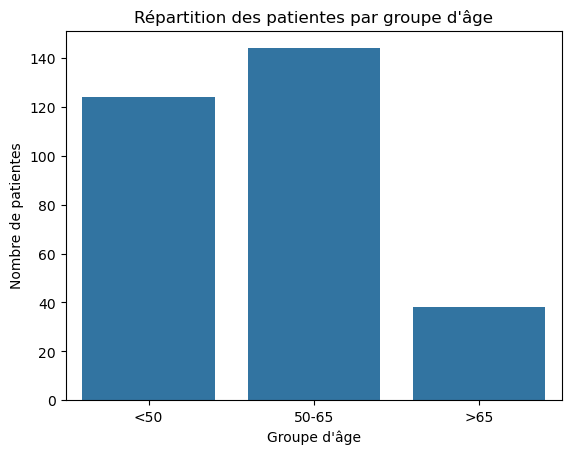

------------------------- AFFICHAGE TERMINÉ AVEC SEABORN --------------
------------------VERIFICATION DU FICHIER SAUVEGARDE----------------------------------
   Age_of_patient_at_time_of_operation  Patient_year_of_operation  \
0                                   30                         64   
1                                   30                         62   
2                                   30                         65   
3                                   31                         59   
4                                   31                         65   

   Number_of_positive_axillary_nodes_detected  Survival_status age_group  
0                                           1                1       <50  
1                                           3                1       <50  
2                                           0                1       <50  
3                                           2                1       <50  
4                                           4      

In [40]:
# Mini-projet : Nettoyage du dataset "Haberman" (Kaggle)
# Étapes :
# 1. Charger le fichier haberman.csv
# 2. Vérifier et supprimer les valeurs manquantes (s'il y en a)
# 3. Ajouter une colonne "age_group" : "<50", "50-65", ">65"
# 4. Visualiser la répartition des groupes d'âge
# 5. Sauvegarder le DataFrame nettoyé en haberman_clean.csv

import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

# 1. Charger le dataset
patient = pd.read_csv("haberman.csv")   # Lecture du fichier CSV avec Pandas

# 2. Vérifier les valeurs manquantes
print("------------------VALEUR MANQUANT----------------------------------")
valeurManq = patient.isnull().sum()     # Compte le nombre de valeurs manquantes par colonne
print(valeurManq)                       # Affiche le résultat (ici toutes les colonnes ont 0)

# 3. Ajouter une nouvelle colonne "age_group"
# pd.cut() permet de découper une variable numérique en intervalles (bins)
# Ici, on découpe l'âge en 3 catégories : <50, 50-65, >65
patient["age_group"] = pd.cut(
    patient["Age_of_patient_at_time_of_operation"],  # colonne à découper
    bins=[0, 49, 65, 120],                           # bornes des intervalles
    labels=["<50", "50-65", ">65"]                   # noms des catégories
)

# Vérification : affichage des premières lignes
print("------------------APERCU DU DATAFRAME AVEC age_group----------------------------------")
print(patient.head())

# 4. Analyse : compter combien de patientes dans chaque groupe d'âge
age_group_counts = patient["age_group"].value_counts()
print("------------------REPARTITION PAR GROUPE D'AGE----------------------------------")
print(age_group_counts)

# Visualisation avec Seaborn
sns.barplot(x=age_group_counts.index, y=age_group_counts.values)
plt.title("Répartition des patientes par groupe d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Nombre de patientes")
plt.show()

print("------------------------- AFFICHAGE TERMINÉ AVEC SEABORN --------------")

# 5. Sauvegarder le DataFrame nettoyé
# index=False : indique à Pandas de ne pas sauvegarder la colonne des index (0,1,2,...) dans le fichier CSV
patient.to_csv("haberman_clean.csv", index=False)

# Vérification : recharger le fichier sauvegardé
df_clean = pd.read_csv("haberman_clean.csv")
print("------------------VERIFICATION DU FICHIER SAUVEGARDE----------------------------------")
print(df_clean.head())
